In [27]:
import pandas as pd
import numpy as np


df = pd.read_csv('zepto_simulated_orders.csv')
df

,Timestamp,Dark_Store,Category,Product_Name,Selling_Price,Quantity_Ordered,Status
0,2026-04-01 00:07:00,Store_Patna_RajaBazar,Chocolates & Candies,"Kurkure Green Chutney, Rajasthani Style",2000,1,Bounced (Out of Stock)
1,2026-04-01 00:09:00,Store_Patna_RajaBazar,Ice Cream & Desserts,Safal Frozen - Mixed Vegetables,10500,2,Delivered
2,2026-04-01 00:12:00,Store_Patna_RajaBazar,Chocolates & Candies,Pedigree Dog Food Adult Chicken & Veg,59400,2,Delivered
3,2026-04-01 00:18:00,Store_Patna_BoringRoad,Packaged Food,Smith & Jones White Pasta Sauce Mix,4000,1,Delivered
4,2026-04-01 00:18:00,Store_Patna_BoringRoad,"Dairy, Bread & Batter",The Laughing Cow Plain Processed Cheese Block,15000,1,Delivered
...,...,...,...,...,...,...,...
23268,2026-04-30 23:41:00,Store_Patna_RajaBazar,Biscuits,Bauli Moonfils Veg - Strawberry,1500,1,Delivered
23269,2026-04-30 23:48:00,Store_Patna_BoringRoad,Chocolates & Candies,Veeba Salsa Dip,11100,1,Delivered
23270,2026-04-30 23:49:00,Store_Patna_RajaBazar,"Dairy, Bread & Batter",Go Cheese Spread - Four Pepper (Soft & Creamy),9400,1,Delivered
23271,2026-04-30 23:51:00,Store_Patna_Kankatbagh,Munchies,Popular Essentials Premium Jeera Rice,14000,1,Delivered


In [28]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Timestamp']

0       2026-04-01 00:07:00
1       2026-04-01 00:09:00
2       2026-04-01 00:12:00
3       2026-04-01 00:18:00
4       2026-04-01 00:18:00
                ...        
23268   2026-04-30 23:41:00
23269   2026-04-30 23:48:00
23270   2026-04-30 23:49:00
23271   2026-04-30 23:51:00
23272   2026-04-30 23:59:00
Name: Timestamp, Length: 23273, dtype: datetime64[ns]

In [29]:

df['Hour'] = df['Timestamp'].dt.hour
# df['Hour'].head()

In [30]:

bounce_matrix = df.groupby('Hour')['Status'].value_counts(normalize=True).unstack().fillna(0)
bounce_matrix

Status,Bounced (Out of Stock),Delivered
Hour,,
0,0.132308,0.867692
1,0.102601,0.897399
2,0.127168,0.872832
3,0.122419,0.877581
4,0.104478,0.895522
5,0.110778,0.889222
6,0.114961,0.885039
7,0.124242,0.875758
8,0.126677,0.873323


In [31]:

bounce_matrix['Bounce_Rate_%'] = bounce_matrix['Bounced (Out of Stock)'] * 100
bounce_matrix['Bounce_Rate_%']

Hour
0     13.230769
1     10.260116
2     12.716763
3     12.241888
4     10.447761
5     11.077844
6     11.496063
7     12.424242
8     12.667660
9     10.136157
10    11.659193
11    13.262195
12    11.976912
13    11.470588
14    12.052117
15    10.751105
16    14.583333
17    10.350584
18    24.235808
19    26.141227
20    24.329359
21    26.016260
22    13.043478
23    11.283498
Name: Bounce_Rate_%, dtype: float64

In [32]:

print(bounce_matrix[['Bounce_Rate_%']].sort_values(by='Bounce_Rate_%', ascending=False).head())

Status  Bounce_Rate_%
Hour                 
19          26.141227
21          26.016260
20          24.329359
18          24.235808
16          14.583333


In [33]:

hourly_demand = df.groupby('Hour').size().reset_index(name='Total_Orders')
hourly_demand

,Hour,Total_Orders
0,0,650
1,1,692
2,2,692
3,3,678
4,4,670
5,5,668
6,6,635
7,7,660
8,8,671
9,9,661


In [34]:
hourly_demand['Rolling_Avg_3h'] = hourly_demand['Total_Orders'].rolling(window=3, min_periods=1).mean()

hourly_demand['Rolling_Avg_3h'] 

0      650.000000
1      671.000000
2      678.000000
3      687.333333
4      680.000000
5      672.000000
6      657.666667
7      654.333333
8      655.333333
9      664.000000
10     667.000000
11     662.000000
12     672.666667
13     676.333333
14     662.333333
15     657.666667
16     655.000000
17     650.000000
18    1339.666667
19    2050.333333
20    2745.333333
21    2403.333333
22    1691.000000
23    1032.666667
Name: Rolling_Avg_3h, dtype: float64

In [35]:
print("--- HOURLY DEMAND WITH 3-HOUR ROLLING AVERAGE ---")
print(hourly_demand.sort_values(by='Rolling_Avg_3h', ascending=False).head())

--- HOURLY DEMAND WITH 3-HOUR ROLLING AVERAGE ---
    Hour  Total_Orders  Rolling_Avg_3h
20    20          2684     2745.333333
21    21          1722     2403.333333
19    19          2804     2050.333333
22    22           667     1691.000000
18    18          2748     1339.666667


In [36]:

category_analysis = df.groupby('Category').agg(
    Total_Orders=('Quantity_Ordered', 'count'),
    Total_Qty_Sold=('Quantity_Ordered', 'sum'),
    Bounced_Orders=('Status', lambda x: (x == 'Bounced (Out of Stock)').sum())
).reset_index()

category_analysis


,Category,Total_Orders,Total_Qty_Sold,Bounced_Orders
0,Beverages,793,1121,210
1,Biscuits,879,1222,294
2,Chocolates & Candies,2416,3376,404
3,Cooking Essentials,3297,4594,567
4,"Dairy, Bread & Batter",798,1101,204
5,Fruits & Vegetables,513,716,63
6,Health & Hygiene,598,847,133
7,Home & Cleaning,1174,1628,176
8,Ice Cream & Desserts,2443,3375,405
9,"Meats, Fish & Eggs",362,477,72


In [37]:
category_analysis['Category_Bounce_Rate_%'] = (category_analysis['Bounced_Orders'] / category_analysis['Total_Orders']) * 100

category_analysis['Category_Bounce_Rate_%']


0     26.481715
1     33.447099
2     16.721854
3     17.197452
4     25.563910
5     12.280702
6     22.240803
7     14.991482
8     16.577978
9     19.889503
10    18.058191
11    13.286052
12    17.632752
13    11.702128
Name: Category_Bounce_Rate_%, dtype: float64

In [38]:
print("--- CATEGORY PERFORMANCE ---")
print(category_analysis.sort_values(by='Total_Qty_Sold', ascending=False))

--- CATEGORY PERFORMANCE ---
                 Category  Total_Orders  Total_Qty_Sold  Bounced_Orders  \
3      Cooking Essentials          3297            4594             567   
10               Munchies          3162            4444             571   
12          Packaged Food          2467            3443             435   
2    Chocolates & Candies          2416            3376             404   
8    Ice Cream & Desserts          2443            3375             405   
13          Personal Care          2256            3187             264   
11            Paan Corner          2115            2927             281   
7         Home & Cleaning          1174            1628             176   
1                Biscuits           879            1222             294   
0               Beverages           793            1121             210   
4   Dairy, Bread & Batter           798            1101             204   
6        Health & Hygiene           598             847             133

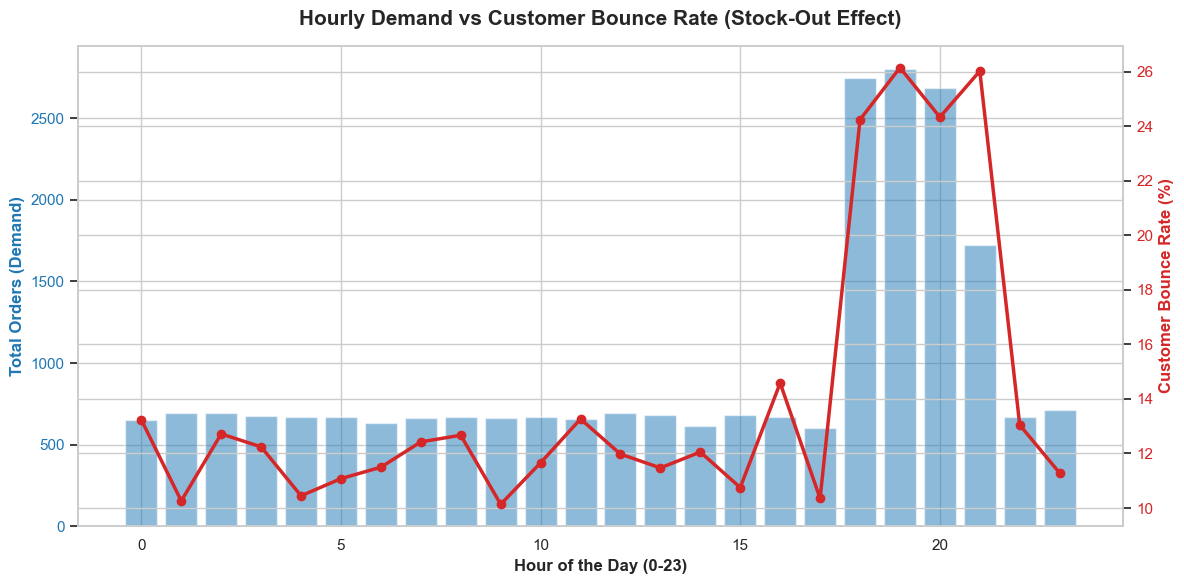

C:\Users\BIT PATNA\AppData\Local\Temp\ipykernel_12780\447742798.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category_Bounce_Rate_%', y='Category', data=category_analysis, palette='coolwarm', ax=ax)


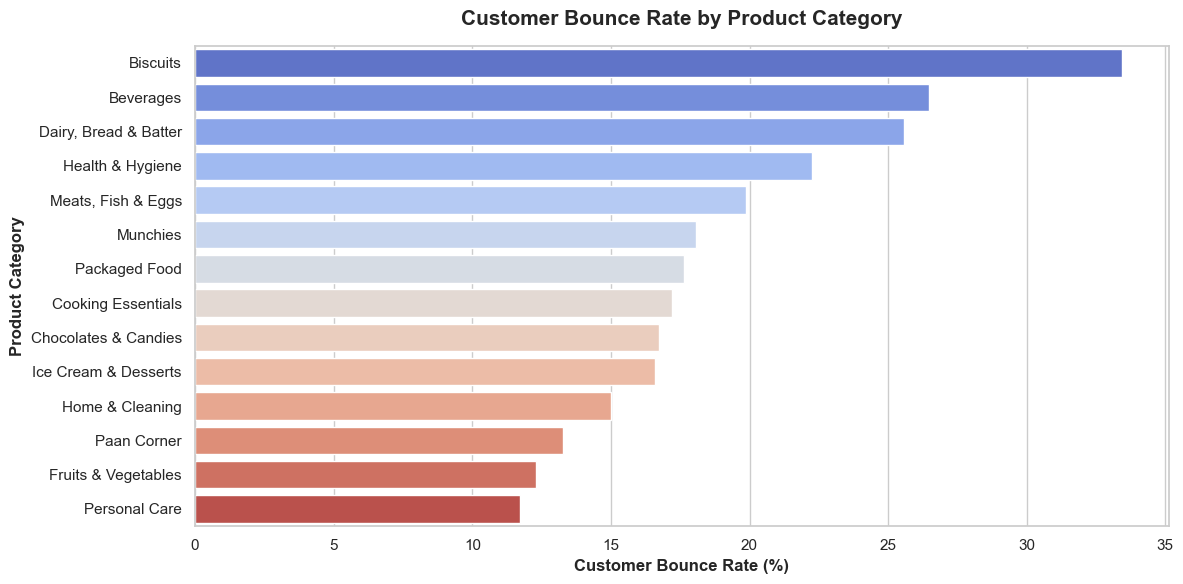

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")


fig, ax1 = plt.subplots(figsize=(12, 6))


color = 'tab:blue'
ax1.set_xlabel('Hour of the Day (0-23)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Orders (Demand)', color=color, fontsize=12, fontweight='bold')
ax1.bar(hourly_demand['Hour'], hourly_demand['Total_Orders'], color=color, alpha=0.5, label='Total Orders')
ax1.tick_params(axis='y', labelcolor=color)


ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Customer Bounce Rate (%)', color=color, fontsize=12, fontweight='bold')
ax2.plot(bounce_matrix.index, bounce_matrix['Bounce_Rate_%'], color=color, linewidth=2.5, marker='o', label='Bounce Rate %')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Hourly Demand vs Customer Bounce Rate (Stock-Out Effect)', fontsize=15, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()



category_analysis = category_analysis.sort_values(by='Category_Bounce_Rate_%', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='Category_Bounce_Rate_%', y='Category', data=category_analysis, palette='coolwarm', ax=ax)

ax.set_xlabel('Customer Bounce Rate (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Product Category', fontsize=12, fontweight='bold')
ax.set_title('Customer Bounce Rate by Product Category', fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.show() 